In [1]:
import geopandas as gpd
import datetime
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tx_fast_hydrology.muskingum import Muskingum, ModelCollection, Connection
from tx_fast_hydrology.simulation import AsyncSimulation

In [2]:
shoal= gpd.read_file('../data/ShoalWaller_den/Splitline_Trimmed_Shoal.shp')
shoal= shoal.to_crs("EPSG:4326")
shoal # SplitID is not unique but GridID [or HydroID] is 

,arcid,GridID,Shape_Leng,OrigLength,SplitID,HydroID,From_Node,To_Node,NextDownID,PU_Order,DrainID,LengthKM,geometry
0,1,3578,539.037192,539.037192,3520,3578,1,2,3579,1,3790,0.164299,"LINESTRING (-97.73889 30.38132, -97.73888 30.3..."
1,3,3579,908.957019,908.957019,3522,3579,2,3,3602,4,3791,0.277051,"LINESTRING (-97.73745 30.38117, -97.73743 30.3..."
2,7,3580,1734.160458,1734.160458,3526,3580,4,5,3613,7,3792,0.528573,"LINESTRING (-97.73718 30.3696, -97.73718 30.36..."
3,13,3581,1415.009603,1415.009603,3532,3581,6,7,3621,10,3793,0.431296,"LINESTRING (-97.73951 30.35787, -97.73951 30.3..."
4,2,3594,2610.168010,7830.504030,3521,3594,25,26,3595,1,3806,0.795581,"LINESTRING (-97.73958 30.39473, -97.73955 30.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,46,3690,2283.718045,9134.872180,3565,3690,116,117,3691,1,3902,0.696079,"LINESTRING (-97.74515 30.28363, -97.74515 30.2..."
63,46,3691,2283.718045,9134.872180,3565,3691,117,118,3692,2,3903,0.696079,"LINESTRING (-97.74356 30.27974, -97.74356 30.2..."
64,46,3692,2283.718045,9134.872180,3565,3692,118,119,3693,3,3904,0.696079,"LINESTRING (-97.7463 30.27547, -97.74632 30.27..."
65,46,3693,2283.718045,9134.872180,3565,3693,119,115,3701,4,3905,0.696079,"LINESTRING (-97.74749 30.27045, -97.74749 30.2..."


In [3]:
waller = gpd.read_file('../data/ShoalWaller_den/Splitline_Trimmed_Waller.shp')
waller = waller.to_crs("EPSG:4326")
waller # SplitID is not unique but GridID [or HydroID] is 

,arcid,GridID,Shape_Leng,OrigLength,SplitID,HydroID,From_Node,To_Node,NextDownID,PU_Order,DrainID,LengthKM,geometry
0,29,3582,2097.934781,2097.934781,3548,3582,8,9,3665,1,3794,0.639452,"LINESTRING (-97.72943 30.30189, -97.72943 30.3..."
1,34,3583,111.182995,111.182995,3553,3583,10,11,3673,14,3795,0.033889,"LINESTRING (-97.73408 30.28824, -97.73408 30.2..."
2,37,3584,1132.785755,1132.785755,3556,3584,12,13,3677,1,3796,0.345274,"LINESTRING (-97.72821 30.28102, -97.72822 30.2..."
3,38,3585,494.199130,494.199130,3557,3585,14,13,3677,1,3797,0.150632,"LINESTRING (-97.72821 30.27867, -97.72822 30.2..."
4,41,3586,2048.511776,2048.511776,3560,3586,15,16,3589,1,3798,0.624388,"LINESTRING (-97.72843 30.27352, -97.72843 30.2..."
5,42,3587,2216.029137,2216.029137,3561,3587,17,16,3589,1,3799,0.675447,"LINESTRING (-97.72705 30.26976, -97.72707 30.2..."
6,43,3588,1494.778272,1494.778272,3562,3588,18,19,3590,19,3800,0.455609,"LINESTRING (-97.73559 30.27197, -97.73559 30.2..."
7,44,3589,2037.596938,2037.596938,3563,3589,16,19,3590,2,3801,0.621061,"LINESTRING (-97.73123 30.27065, -97.73123 30.2..."
8,47,3590,1159.112363,1159.112363,3566,3590,19,20,3591,20,3802,0.353298,"LINESTRING (-97.73502 30.26893, -97.73502 30.2..."
9,49,3591,1191.696153,1191.696153,3568,3591,20,21,3592,21,3803,0.363230,"LINESTRING (-97.73569 30.26677, -97.73569 30.2..."


In [4]:
assert (shoal['GridID'] == shoal['HydroID']).all()
assert (waller['GridID'] == waller['HydroID']).all()

In [5]:
shoal['reach_ids'] = shoal['HydroID'].astype('str')
shoal['dx'] = shoal['LengthKM']*1000
shoal['K'] = shoal['dx'] / 2.12
shoal['X'] = [0.25 for i in range(shoal['reach_ids'].size)]
shoal['o_t'] = [0 for i in range(shoal['reach_ids'].size)]
shoal['startnodes'] = [i for i in range(shoal['reach_ids'].size)]

waller['reach_ids'] = waller['HydroID'].astype('str')
waller['dx'] = waller['LengthKM']*1000
waller['K'] = waller['dx'] / 2.12
waller['X'] = [0.25 for i in range(waller['reach_ids'].size)]
waller['o_t'] = [0 for i in range(waller['reach_ids'].size)]
waller ['startnodes'] = [i for i in range(waller['reach_ids'].size)]

# $\Delta$T

In [6]:
print(f'Using the mean K, \u0394T must be less than {(2*shoal['K'].values.mean()*(1-0.25)).item()} seconds for shoal')
print(f'Using the min K, \u0394T must be less than {(2*shoal['K'].values.min()*(1-0.25)).item()} seconds for shoal')
print(f'Using the max K, \u0394T must be less than {(2*shoal['K'].values.max()*(1-0.25)).item()} seconds for shoal')
print()
print(f'Using the mean K, \u0394T must be less than {(2*waller['K'].values.mean()*(1-0.25)).item()} seconds for waller')
print(f'Using the min K, \u0394T must be less than {(2*waller['K'].values.min()*(1-0.25)).item()} seconds for waller')
print(f'Using the max K, \u0394T must be less than {(2*waller['K'].values.max()*(1-0.25)).item()} seconds for waller')

Using the mean K, ΔT must be less than 502.8391336277175 seconds for shoal
Using the min K, ΔT must be less than 116.24919672665094 seconds for shoal
Using the max K, ΔT must be less than 635.1902792356132 seconds for shoal

Using the mean K, ΔT must be less than 467.3514957627384 seconds for waller
Using the min K, ΔT must be less than 23.977814539386788 seconds for waller
Using the max K, ΔT must be less than 642.1431551695755 seconds for waller


In [7]:
endnodes = []
for i,v in enumerate(shoal['NextDownID'].values):
    if v in shoal['HydroID'].values:
        index = shoal[shoal['HydroID']== v].index[0]
        endnodes.append(shoal ['startnodes'][index].item())
    else:
        endnodes.append(shoal['startnodes'][i].item())
shoal['endnodes'] = endnodes


endnodes = []
for i,v in enumerate(waller['NextDownID'].values):
    if v in waller['HydroID'].values:
        index = waller[waller['HydroID']== v].index[0]
        endnodes.append(waller ['startnodes'][index].item())
    else:
        endnodes.append(waller['startnodes'][i].item())
waller['endnodes'] = endnodes

In [8]:
paths = []

for line in shoal['geometry']:
    coords = list(line.coords)  # Extract list of (x, y) tuples
    path = [[x, y] for x, y in coords]  # Convert to nested list
    paths.append([path])  # Match the structure: paths[i][0][j] = [x, y]

# Now wrap in a dict if you want to export to JSON
#paths_json = {"paths": paths}
shoal_dict = {
    'reach_ids': shoal['reach_ids'].to_list(),
    'startnodes': shoal['startnodes'].to_list(),
    'endnodes': shoal ['endnodes'].to_list(),
    'K': shoal['K'].to_list(),
    'X': shoal['X'].to_list(),
    'o_t': shoal['o_t'].to_list(),
    'dx': shoal['dx'].to_list(),
    'paths': paths,
}
shoal_dict['datetime'] = '2024-12-31T23:58:00+00:00'
shoal_dict['timedelta'] = 'P0DT0H0M20S'
shoal_dict['name'] = "SHL"
shoal_dict = {'model': shoal_dict}
shoal_dict['sinks'] = []
shoal_dict['sources'] = []

In [9]:
paths = []

for line in waller['geometry']:
    coords = list(line.coords)  # Extract list of (x, y) tuples
    path = [[x, y] for x, y in coords]  # Convert to nested list
    paths.append([path])  # Match the structure: paths[i][0][j] = [x, y]

# Now wrap in a dict if you want to export to JSON
#paths_json = {"paths": paths}
waller_dict = {
    'reach_ids': waller['reach_ids'].to_list(),
    'startnodes': waller['startnodes'].to_list(),
    'endnodes': waller ['endnodes'].to_list(),
    'K': waller['K'].to_list(),
    'X': waller['X'].to_list(),
    'o_t': waller['o_t'].to_list(),
    'dx': waller['dx'].to_list(),
    'paths': paths,
}
waller_dict['datetime'] = '2024-12-31T23:58:00+00:00'
waller_dict['timedelta'] = 'P0DT0H0M20S'
waller_dict['name'] = "WAL"
waller_dict = {'model': waller_dict}
waller_dict['sinks'] = []
waller_dict['sources'] = []

In [10]:
shoal_waller_dict = {"SHL": shoal_dict, "WAL": waller_dict}
shoal_waller_dict = {'models': shoal_waller_dict}
shoal_waller_dict['connections'] = {}
shoal_waller_dict.keys()

dict_keys(['models', 'connections'])

In [11]:
with open('../data/shoal_waller_less_densified_partitioned.json', 'w') as f:
    json.dump(shoal_waller_dict, f, indent=2)

In [13]:
# Define model file input path
input_path = '../data/shoal_waller_less_densified_partitioned.json'
# Load model collection from file
model_collection = ModelCollection.from_file(input_path)

Text(0.5, 1.0, 'Shoal and Waller')

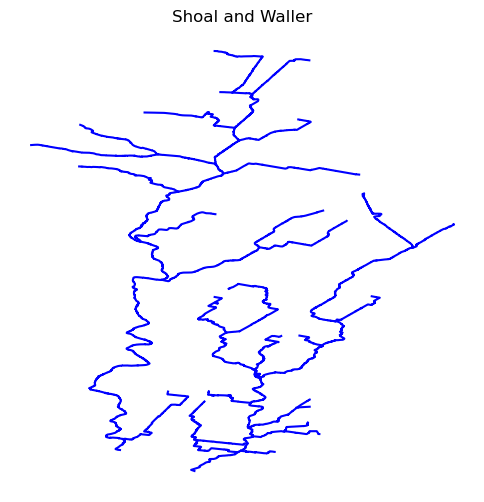

In [14]:
# Shoal creek and waller creek
fig, ax = plt.subplots(figsize=(6,6))
for model_name, model in model_collection.models.items():
    model.plot(ax=ax, c='b')
plt.axis('off')
plt.title('Shoal and Waller')

In [ ]:
model_collection.dump_model_collection('../data/shoal_waller_less_densified_partitioned.json')

# 

# 